# FineWeb-Edu Data Exploration

Exploratory data analysis of the FineWeb-Edu Sample-10BT dataset using Apache Spark on SDSC Expanse HPC.

In [1]:
!pip install -qq pyspark matplotlib seaborn pandas

import os
import sys
from pathlib import Path

# Get the parent directory and add it to the path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Set matplotlib cache directory to avoid write permission warnings
mpl_cache_dir = os.path.join(os.getcwd(), ".mpl_cache")
os.makedirs(mpl_cache_dir, exist_ok=True)
os.environ['MPLCONFIGDIR'] = mpl_cache_dir

import pandas as pd
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns

## Downloading Data
Download the 14 FineWeb-Edu parquet files from HuggingFace into the local `../data` directory. Files are skipped if already downloaded.

In [2]:
from fineweb_spark.dataset import download_fineweb_sample

download_fineweb_sample()

All 14 sample files downloaded.


## Spark Session
Initialize Spark with 7 executors and 15GB memory each, optimized for an 8-core, 128GB Expanse node.

In [3]:
# Create SparkSession with specified configurations
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "15g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

spark

## Load Dataset
Read all 14 parquet files into a single Spark DataFrame.

In [4]:
from fineweb_spark.paths import RAW_DATA_DIR

df = spark.read.parquet(str(RAW_DATA_DIR))

## Schema & Basic Counts
Inspect column names, types, and total number of rows.

In [5]:
# Show the schema of the DataFrame to verify it loaded correctly
df.printSchema()

root
 |-- text: string (nullable = true)
 |-- id: string (nullable = true)
 |-- dump: string (nullable = true)
 |-- url: string (nullable = true)
 |-- file_path: string (nullable = true)
 |-- language: string (nullable = true)
 |-- language_score: double (nullable = true)
 |-- token_count: long (nullable = true)
 |-- score: double (nullable = true)
 |-- int_score: long (nullable = true)



In [6]:
%%time
# Total number of rows
print(f"Total rows: {df.count():,}")

Total rows: 9,672,101
CPU times: user 389 µs, sys: 507 µs, total: 896 µs
Wall time: 2.57 s


In [7]:
%%time
# How many partitions Spark created (affects parallelism)
print(f"Number of partitions: {df.rdd.getNumPartitions()}")

Number of partitions: 213
CPU times: user 397 µs, sys: 1.25 ms, total: 1.64 ms
Wall time: 89.9 ms


In [8]:
# Show what rows look like and substring(text, 1, 200) shows only the first 200 chars to keep output readable.

from pyspark.sql import functions as F

df.select(
    "id",
    "language",
    "language_score",
    "token_count",
    "score",
    "int_score",
    F.substring("text", 1, 200).alias("text_preview")
).show(10, truncate=40)


+----------------------------------------+--------+------------------+-----------+--------+---------+----------------------------------------+
|                                      id|language|    language_score|token_count|   score|int_score|                            text_preview|
+----------------------------------------+--------+------------------+-----------+--------+---------+----------------------------------------+
|<urn:uuid:7dac48da-7e84-4d0e-8a1a-896...|      en|0.9268330931663513|       6510| 3.28125|        3|Bromide in the Allegheny River System...|
|<urn:uuid:28c8caae-db0c-4a28-8c20-f2f...|      en|0.9184828996658325|        597|3.796875|        4|You need to add organic waste in the ...|
|<urn:uuid:9918a374-c3c5-451c-9f06-19c...|      en|0.9499439001083374|        667|3.328125|        3|How a Memory Foam Mattress Is Made\nH...|
|<urn:uuid:adcc1847-c256-461d-8dab-90e...|      en|0.9136435389518738|        806|3.203125|        3|Main Article Content\nBackground: Bre...|

## Summary Statistics
Compute mean, min, max, and standard deviation for all numeric columns using `df.describe()`.

In [9]:
# Summary statistics for key numeric features
df.select(
    "language_score",
    "token_count",
    "score",
    "int_score"
).summary().show()

+-------+--------------------+------------------+------------------+-----------------+
|summary|      language_score|       token_count|             score|        int_score|
+-------+--------------------+------------------+------------------+-----------------+
|  count|             9672101|           9672101|           9672101|          9672101|
|   mean|  0.9362028150343236|1031.1015338859675| 3.006352990485211|3.133958278558092|
| stddev|0.041480192617279976|1866.7273525667142|0.3978527655254993|0.342855433072758|
|    min|  0.6500054001808167|                42|          2.515625|                3|
|    25%|  0.9241560697555542|               349|            2.6875|                3|
|    50%|  0.9459684491157532|               629|           2.90625|                3|
|    75%|  0.9615052938461304|              1091|              3.25|                3|
|    max|  0.9994099140167236|            170927|           5.34375|                5|
+-------+--------------------+-------------

In [10]:
# Observe how document length varies by each score bucket
quality_bucket = (
    df.groupBy("int_score")
      .agg(
          F.count("*").alias("n_docs"),
          F.avg("token_count").alias("avg_tokens")
      )
      .orderBy("int_score")
)
quality_bucket.show()

+---------+-------+------------------+
|int_score| n_docs|        avg_tokens|
+---------+-------+------------------+
|        3|8383873|1022.5527939175605|
|        4|1280798|1087.8567346295044|
|        5|   7430| 893.7667563930014|
+---------+-------+------------------+



## Documents per Quality Bucket
Group by `int_score` to see how many documents fall in each quality tier and plot as a bar chart.

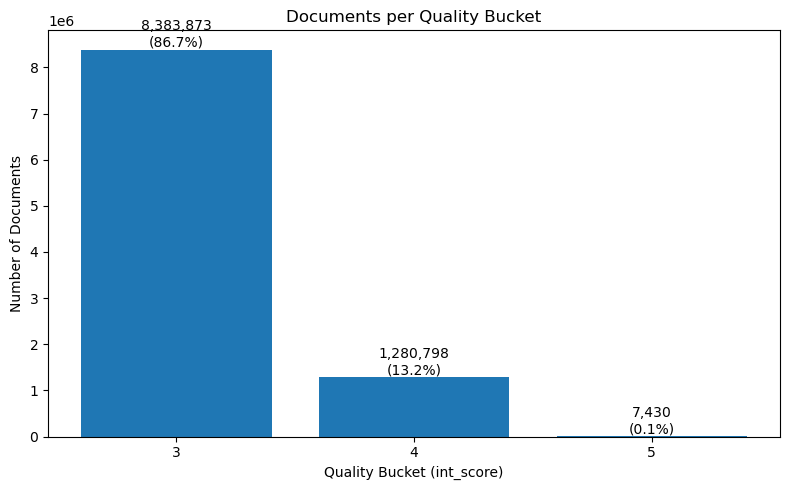

In [11]:
pdf = quality_bucket.toPandas()

plt.figure(figsize=(8,5))
bars = plt.bar(pdf["int_score"], pdf["n_docs"])

plt.xlabel("Quality Bucket (int_score)")
plt.ylabel("Number of Documents")
plt.title("Documents per Quality Bucket")

plt.xticks(pdf["int_score"])

# Add labels
total = pdf["n_docs"].sum()
for i, v in enumerate(pdf["n_docs"]):
    pct = v / total * 100
    plt.text(pdf["int_score"][i],
             v,
             f"{v:,}\n({pct:.1f}%)",
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()

## Domain Analysis
Extract source domains from URLs and identify the most frequent ones. High diversity indicates content is sourced from many websites.

In [12]:
# How many unique web domains? Which are the most frequently occurring?
from pyspark.sql.functions import regexp_extract

df_domains = df.withColumn(
    "domain",
    regexp_extract("url", r"https?://([^/]+)", 1)
)
distinct_url = df_domains.select("domain").distinct().count()
print("Unique Domains:", distinct_url)

top_domains = df_domains.groupBy("domain") \
    .count() \
    .orderBy("count", ascending=False)

top_domains.show(20, truncate=False)

Unique Domains: 2088546
+---------------------------+-----+
|domain                     |count|
+---------------------------+-----+
|en.wikipedia.org           |64429|
|www.britannica.com         |22569|
|www.reference.com          |22180|
|www.enotes.com             |19872|
|phys.org                   |15223|
|www.teacherspayteachers.com|14453|
|www.sciencedaily.com       |13442|
|www.eurekalert.org         |12887|
|www.bookrags.com           |11953|
|slideplayer.com            |11264|
|www.newscientist.com       |11264|
|en.wikisource.org          |10638|
|www.redorbit.com           |10565|
|www.oxforddictionaries.com |10179|
|www.gardenguides.com       |9573 |
|simple.wikipedia.org       |9521 |
|www.theguardian.com        |9232 |
|www.studymode.com          |8641 |
|everything2.com            |8247 |
|www.livestrong.com         |8072 |
+---------------------------+-----+
only showing top 20 rows



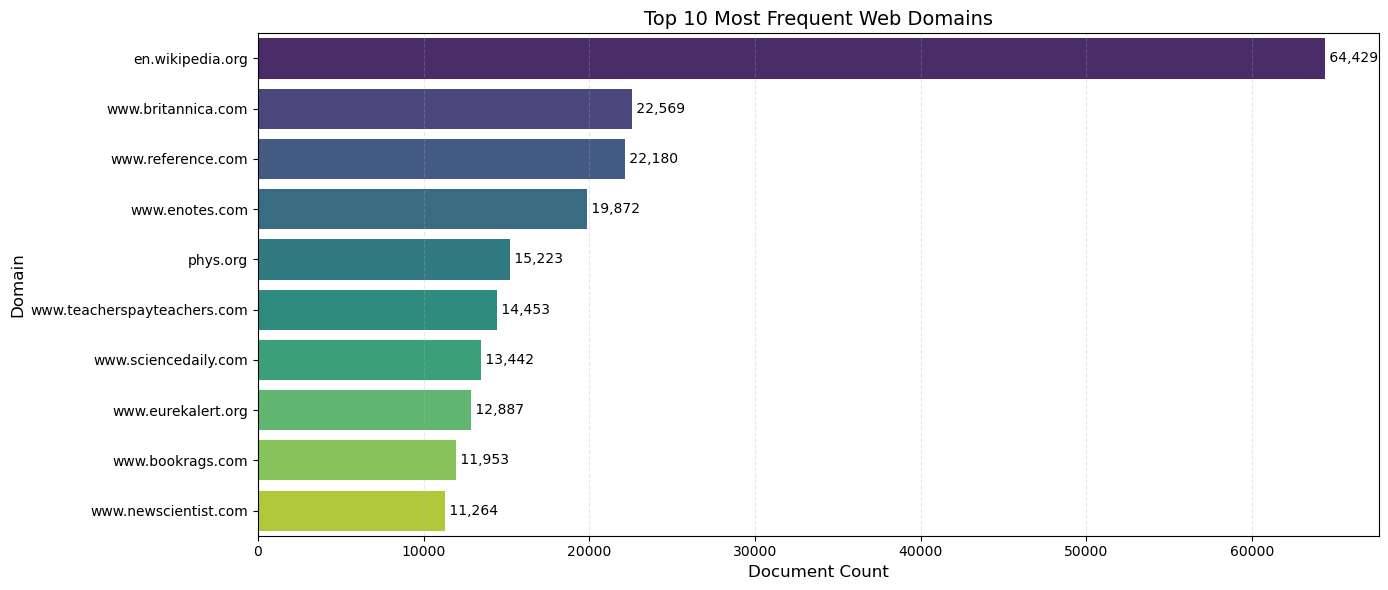

In [13]:
# Convert to pandas
top_domains_pdf = top_domains.limit(10).toPandas()

plt.figure(figsize=(14, 6))
sns.barplot(data=top_domains_pdf, x="count", y="domain", palette='viridis', hue="domain", legend=False)
plt.title("Top 10 Most Frequent Web Domains", fontsize=14)
plt.xlabel("Document Count", fontsize=12)
plt.ylabel("Domain", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
# Add counts to bars
for index, row in top_domains_pdf.iterrows():
    plt.text(row['count'], index, f" {row['count']:,}", va='center', fontsize=10)
plt.tight_layout()
plt.show()

## Missing & Duplicate Values
Check for null values across all columns and identify empty text rows.

In [ ]:
# Count nulls per column to check missingness
null_counts = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)

# Specifically check empty text rows (null or length 0)
df.select(
    F.sum((F.col("text").isNull() | (F.length("text") == 0)).cast("int")).alias("empty_text_rows")
).show()

+----+---+----+---+---------+--------+--------------+-----------+-----+---------+
|text|id |dump|url|file_path|language|language_score|token_count|score|int_score|
+----+---+----+---+---------+--------+--------------+-----------+-----+---------+
|0   |0  |0   |0  |0        |0       |0             |0          |0    |0        |
+----+---+----+---+---------+--------+--------------+-----------+-----+---------+

+---------------+
|empty_text_rows|
+---------------+
|              0|
+---------------+



## Token Count & Score Distributions
Compute min, median, mean, and max for `token_count` and `score` using Spark percentile approximation.

In [ ]:
# token_count summary: shows scale and skew (min/median/mean/max)
df.select(
    F.min("token_count").alias("min_tokens"),
    F.expr("percentile_approx(token_count, 0.5)").alias("median_tokens"),
    F.mean("token_count").alias("mean_tokens"),
    F.max("token_count").alias("max_tokens")
).show()

# score summary: range and central tendency
df.select(
    F.min("score").alias("min_score"),
    F.expr("percentile_approx(score, 0.5)").alias("median_score"),
    F.mean("score").alias("mean_score"),
    F.max("score").alias("max_score")
).show()

+----------+-------------+------------------+----------+
|min_tokens|median_tokens|       mean_tokens|max_tokens|
+----------+-------------+------------------+----------+
|        42|          629|1031.1015338859675|    170927|
+----------+-------------+------------------+----------+

+---------+------------+-----------------+---------+
|min_score|median_score|       mean_score|max_score|
+---------+------------+-----------------+---------+
| 2.515625|     2.90625|3.006352990485211|  5.34375|
+---------+------------+-----------------+---------+



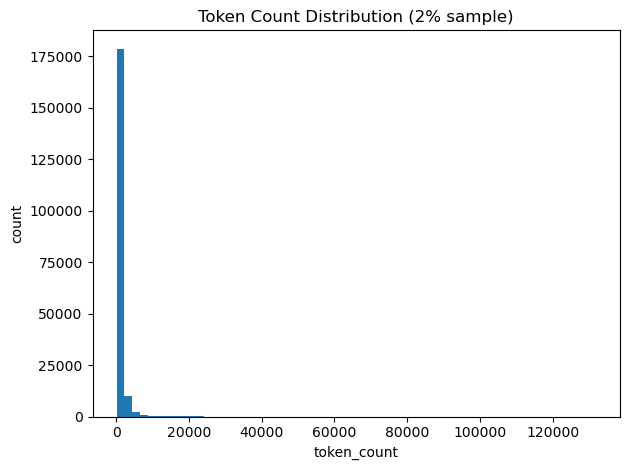

In [ ]:
# Convert a small random sample to pandas for plotting with matplotlib.
import matplotlib.pyplot as plt


sample_tokens = (df.select("token_count")
                   .where(F.col("token_count").isNotNull())
                   .sample(False, 0.02, seed=42)   # 2% sample
                   .toPandas())

plt.figure()
plt.hist(sample_tokens["token_count"], bins=60)
plt.title("Token Count Distribution (2% sample)")
plt.xlabel("token_count")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Score Distribution
Distribution of educational quality scores using a 2% random sample (~193K documents).

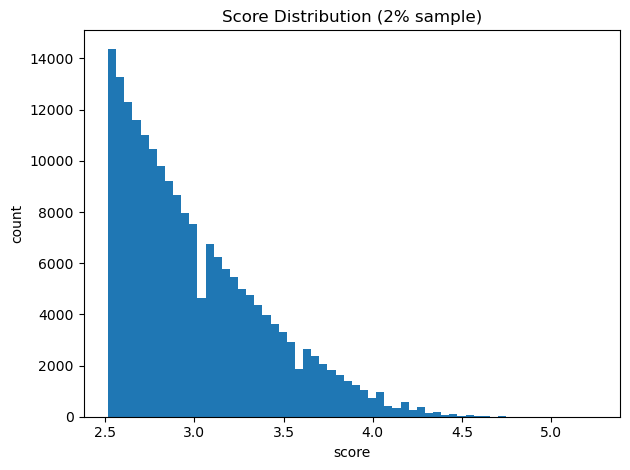

In [ ]:
# Plot distribution of educational quality score
sample_scores = (df.select("score")
                   .where(F.col("score").isNotNull())
                   .sample(False, 0.02, seed=42)   # 2% sample
                   .toPandas())

plt.figure()
plt.hist(sample_scores["score"], bins=60)
plt.title("Score Distribution (2% sample)")
plt.xlabel("score")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Preprocessing Preview
Apply basic filters to estimate how many documents survive cleaning (null text, short documents, low token count, duplicates).

In [18]:
# Preprocessing idea:
# - remove null text
# - remove extremely short documents
# - enforce minimum token_count
# - dedupe by id
clean_df = (df
    .filter(F.col("text").isNotNull())
    .filter(F.length("text") > 200)
    .filter(F.col("token_count") >= 50)
    .dropDuplicates(["id"])
)

print("Rows before cleaning:", df.count())
print("Rows after cleaning:", clean_df.count())

Rows before cleaning: 9672101
Rows after cleaning: 9672072
